In [7]:
from torch_geometric.nn import GAT, GCN, GIN, global_mean_pool, global_max_pool
import torch
import torch.nn as nn
from torch.utils.data import Dataset
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
import pandas as pd
import numpy as np
from torch.utils.data import random_split
from rdkit import Chem
import matplotlib.pyplot as plt

class CTDataset(Dataset):
    def __init__(self, dataframe):
        self.df = dataframe

    def __len__(self):
        return len(self.df)
    
    def mol_to_graph(self, smiles):
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            raise ValueError(f"Invalid SMILES string: {smiles}")

        edge_index = []
        node_features = []
        edge_features = []

        for bond in mol.GetBonds():
            i = bond.GetBeginAtomIdx()
            j = bond.GetEndAtomIdx()

            bond_type = bond.GetBondTypeAsDouble()  # 1.0, 2.0, 3.0, 1.5 (aromatic)
            is_conjugated = bond.GetIsConjugated()
            is_in_ring = bond.IsInRing()

            edge_feat = [bond_type, float(is_conjugated), float(is_in_ring)]

            # Add both directions
            edge_index.append((i, j))
            edge_index.append((j, i))
            edge_features.append(edge_feat)
            edge_features.append(edge_feat)

        # one hot encoding of atom types
        for atom in mol.GetAtoms():
            atom_type = atom.GetAtomicNum()
            aromatic = atom.GetIsAromatic()
            formal_charge = atom.GetFormalCharge()
            hybridization = int(atom.GetHybridization())
            degree = atom.GetDegree()
            valence = atom.GetTotalValence()

            node_features.append([atom_type, aromatic, formal_charge, hybridization, degree, valence])  

        edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
        edge_attr = torch.tensor(edge_features, dtype=torch.float)
        x = torch.tensor(node_features, dtype=torch.float)

        return Data(x=x, edge_index=edge_index, edge_attr=edge_attr)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # fetch graph data
        smiles = row['Canonical SMILES']
        graph_data = self.mol_to_graph(smiles)
        
        # Get labels 
        label = torch.tensor(row['target'], dtype=torch.float)

        return graph_data, label

def main():
    dataset_path = "./ct.parquet"
    df = pd.read_parquet(dataset_path)

    df['X_smi_ted'] = df['X_smi_ted'].apply(lambda x: np.array(x))

    # Create dataset
    dataset = CTDataset(df)
    print("node feature dims", dataset[0][0].x.shape[1])
    dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

    # sample one datapoint from dataset and print node feat dims
    for graph_data, labels in dataloader:
        print(f"Graph data: {graph_data}")
        print(f"Labels shape: {labels.shape}")
        break

if __name__ == "__main__":
    main()

node feature dims 6
Graph data: DataBatch(x=[1018, 6], edge_index=[2, 2024], edge_attr=[2024, 3], batch=[1018], ptr=[33])
Labels shape: torch.Size([32])


In [5]:
class GatingNetwork(nn.Module):
    def __init__(self, in_channels, num_experts, hidden_dim=64, temperature=1.0, num_layers=3, dropout=0.1):
        super().__init__()
        # Graph encoder (GCN)
        self.gate = GCN(
            in_channels=in_channels,
            hidden_channels=hidden_dim,
            out_channels=hidden_dim,   # final embedding size = hidden_dim
            num_layers=num_layers,
            dropout=dropout
        )
        # Map to expert weights
        self.fc = nn.Linear(hidden_dim, num_experts)

        self.temperature = temperature
        self.softmax = nn.Softmax(dim=1)

    def forward(self, x, edge_index, batch):
        h = self.gate(x, edge_index)        # [num_nodes, hidden_dim]
        h = global_mean_pool(h, batch)      # [num_graphs, hidden_dim]
        logits = self.fc(h)                 # [num_graphs, num_experts]
        weights = self.softmax(logits / self.temperature)
        return weights                      # [num_graphs, num_experts]

class Expert(nn.Module):
    def __init__(self, in_channels, out_channels, hidden_dim, heads, dropout, num_layers):
        super().__init__()

        # High-level GAT model from PyG
        self.gnn = GAT(
            in_channels=in_channels,
            hidden_channels=hidden_dim,
            out_channels=hidden_dim,   # <- final embedding size = hidden_dim
            heads=heads,
            dropout=dropout,
            num_layers=num_layers
        )

        # MLP projects hidden_dim -> out_channels
        self.mlp = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, out_channels)
        )

    def forward(self, x, edge_index, batch):
        h = self.gnn(x, edge_index, batch=batch)  # [num_nodes, hidden_dim]
        h = global_mean_pool(h, batch)            # [num_graphs, hidden_dim]
        return self.mlp(h)                        # [num_graphs, out_channels]



class GMoE(nn.Module):
    def __init__(self, num_experts, in_channels, out_channels, att_heads, dropout, num_layers=3, hidden_dim=64):
        super().__init__()
        self.experts = nn.ModuleList([
            Expert(in_channels, out_channels, hidden_dim, att_heads, dropout, num_layers)
            for _ in range(num_experts)
        ])
        self.gating_network = GatingNetwork(in_channels, num_experts, hidden_dim)

    def forward(self, x, edge_index, batch):
        gate_weights = self.gating_network(x, edge_index, batch)   # [num_graphs, num_experts]

        expert_outputs = []
        for i, expert in enumerate(self.experts):
            expert_out = expert(x, edge_index, batch)              # [num_graphs, out_dim]
            expert_outputs.append(expert_out * gate_weights[:, i].view(-1, 1))

        return sum(expert_outputs)

model = GMoE(num_experts=4, in_channels=16, out_channels=32, att_heads=4, dropout=0.1)
print(model)
print(sum(p.numel() for p in model.parameters() if p.requires_grad), "trainable parameters")


GMoE(
  (experts): ModuleList(
    (0-3): 4 x Expert(
      (gnn): GAT(16, 64, num_layers=3)
      (mlp): Sequential(
        (0): Linear(in_features=64, out_features=64, bias=True)
        (1): ReLU()
        (2): Dropout(p=0.1, inplace=False)
        (3): Linear(in_features=64, out_features=32, bias=True)
      )
    )
  )
  (gating_network): GatingNetwork(
    (gate): GCN(16, 64, num_layers=3)
    (fc): Linear(in_features=64, out_features=4, bias=True)
    (softmax): Softmax(dim=1)
  )
)
124484 trainable parameters


In [ ]:
def train_model(model, data_loader, optimizer, criterion, device):
    model.train()
    total_loss = 0

    for data, target in data_loader:
        data = data.to(device)
        target = target.to(device)
        optimizer.zero_grad()
        output = model(data.x, data.edge_index, data.batch)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    return total_loss / len(data_loader)


def test_model(model, data_loader, criterion, device):
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for data, target in data_loader:
            data = data.to(device)
            target = target.to(device)
            output = model(data.x, data.edge_index, data.batch)
            loss = criterion(output, target)
            total_loss += loss.item()

    return total_loss / len(data_loader)

epochs = 20

dataset = CTDataset(pd.read_parquet("./ct.parquet"))
train, test, val = random_split(
    dataset,
    lengths=[0.8, 0.1, 0.1],
    generator=torch.Generator().manual_seed(42)
)

trainLoader = DataLoader(train, batch_size=32, shuffle=True)
valLoader = DataLoader(val, batch_size=32, shuffle=False)
testLoader = DataLoader(test, batch_size=32, shuffle=False)

in_channels = dataset[0][0].x.shape[1]
out_channels = 1
att_heads = 4
dropout = 0.1
num_experts = 5

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = GMoE(in_channels=in_channels, 
             out_channels=out_channels, 
             att_heads=att_heads, 
             dropout=dropout,
             num_experts=num_experts).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

history = {
    "train_loss": [],
    "val_loss": []
}

for epoch in range(epochs):
    train_loss = train_model(model, trainLoader, optimizer, criterion, device)
    val_loss = test_model(model, valLoader, criterion, device)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    print(f"Epoch {epoch+1}/{epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")




/opt/miniconda3/envs/bin-int/lib/python3.12/site-packages/torch/nn/modules/loss.py:616: UserWarning: Using a target size (torch.Size([32])) that is different to the input size (torch.Size([32, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/opt/miniconda3/envs/bin-int/lib/python3.12/site-packages/torch/nn/modules/loss.py:616: UserWarning: Using a target size (torch.Size([30])) that is different to the input size (torch.Size([30, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/opt/miniconda3/envs/bin-int/lib/python3.12/site-packages/torch/nn/modules/loss.py:616: UserWarning: Using a target size (torch.Size([31])) that is different to the input size (torch.Size([31, 1])). This will likely lead to incorrect results due to broadcasting. Please ensu

Epoch 1/20, Train Loss: 1.0229, Val Loss: 0.9615
Epoch 2/20, Train Loss: 1.0221, Val Loss: 0.9637
Epoch 3/20, Train Loss: 1.0212, Val Loss: 0.9628
Epoch 4/20, Train Loss: 1.0216, Val Loss: 0.9633
Epoch 5/20, Train Loss: 1.0213, Val Loss: 0.9642
Epoch 6/20, Train Loss: 1.0213, Val Loss: 0.9638
Epoch 7/20, Train Loss: 1.0209, Val Loss: 0.9637
Epoch 8/20, Train Loss: 1.0216, Val Loss: 0.9635
Epoch 9/20, Train Loss: 1.0211, Val Loss: 0.9642
Epoch 10/20, Train Loss: 1.0212, Val Loss: 0.9634
Epoch 11/20, Train Loss: 1.0208, Val Loss: 0.9640
Epoch 12/20, Train Loss: 1.0212, Val Loss: 0.9652
Epoch 13/20, Train Loss: 1.0214, Val Loss: 0.9646
Epoch 14/20, Train Loss: 1.0214, Val Loss: 0.9634
Epoch 15/20, Train Loss: 1.0209, Val Loss: 0.9639
Epoch 16/20, Train Loss: 1.0211, Val Loss: 0.9642
Epoch 17/20, Train Loss: 1.0209, Val Loss: 0.9640
Epoch 18/20, Train Loss: 1.0209, Val Loss: 0.9646
Epoch 19/20, Train Loss: 1.0207, Val Loss: 0.9645
Epoch 20/20, Train Loss: 1.0220, Val Loss: 0.9638


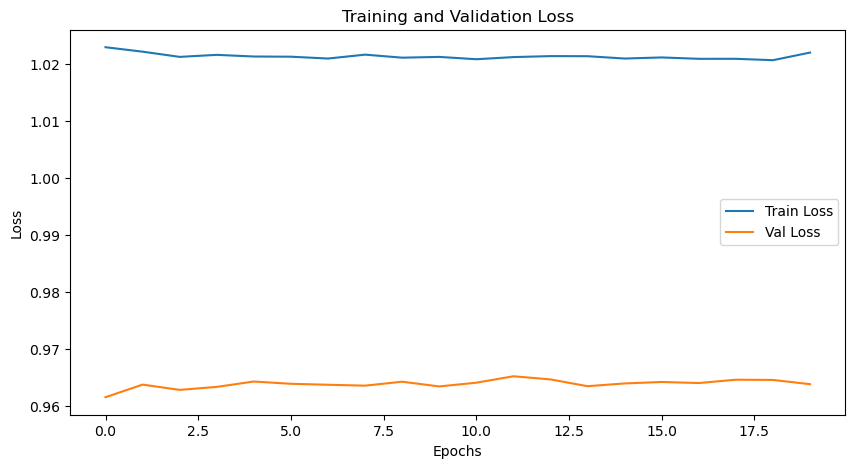

In [8]:
plt.figure(figsize=(10, 5))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Val Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.title("Training and Validation Loss")
plt.show()